In [23]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats

In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

In [3]:
## performance: per seed performance
## lats_performance: avg over seed performance at the end of training
## last_performance_unnormalized: same as last_performance but without normalization
## max_performance: average over seeds (how?) max performance achieved during training (presumably)

# 1. Normalization

In [4]:
# normalization cross-algorithm per environment
data["normed_performance"] = data.groupby("env_name")["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["normed_performance_per_alg"] = data.groupby(["env_name", "algorithm"])["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["_seed_avg"] = data.groupby(["env_name", "algorithm", "config_id"])["performance"].transform("mean")
data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False).apply(
    lambda g: (g["performance"] - g["_seed_avg"].min()) / (g["_seed_avg"].max() - g["_seed_avg"].min() + 1e-8)
)
data.drop(columns=["_seed_avg"], inplace=True)

/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_17896/355322313.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False).apply(


# 2. Metrics

In [5]:
# calc mean and std per config (env_name, algorithm, config_id)
config_stats = data.groupby(["env_name", "algorithm", "config_id"]).agg(
    mean_per_config=("normed_performance", "mean"),
    std_per_config=("normed_performance", "std")
).reset_index()

# calc sharpe ratio per config
config_stats["mean_per_alg"] = config_stats.groupby(["env_name", "algorithm"])["mean_per_config"].transform("mean")
config_stats["Sharpe_ratio"] = (config_stats["mean_per_config"] - config_stats["mean_per_alg"]) / config_stats["std_per_config"]

# Get LCBs per config
config_stats["LCB"] = config_stats["mean_per_config"] - config_stats["std_per_config"]

config_stats.head()

,env_name,algorithm,config_id,mean_per_config,std_per_config,mean_per_alg,Sharpe_ratio,LCB
0,atari_battle_zone,dqn,0,0.038784,0.030913,0.056481,-0.572481,0.007871
1,atari_battle_zone,dqn,1,0.080277,0.063958,0.056481,0.372047,0.016319
2,atari_battle_zone,dqn,2,0.040349,0.055413,0.056481,-0.291130,-0.015064
3,atari_battle_zone,dqn,3,0.089045,0.046115,0.056481,0.706139,0.042930
4,atari_battle_zone,dqn,4,0.059189,0.038576,0.056481,0.070197,0.020613


In [6]:
# delete rows with NaN values in Sharpe_ratio or LCB
full_rows = len(config_stats)
config_stats = config_stats.dropna(subset=["Sharpe_ratio", "LCB"])

print(f"Dropped {full_rows - len(config_stats)} rows with NaN values in Sharpe_ratio or LCB out of {full_rows} total rows.")

Dropped 256 rows with NaN values in Sharpe_ratio or LCB out of 10240 total rows.


In [7]:
def per_alg_plot(
        plot_data: pd.DataFrame,
        x: str,
        ycols: list[str],
        algs: list[str]
    ):

    

    n_cols = 3
    n_rows = len(algs)
    n_envs = len(plot_data["env_name"].unique())

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten()

    for i, alg in enumerate(algs):
        
        sub_data = plot_data[plot_data["algorithm"] == alg]

        for j, y in enumerate(ycols):
            ax = axes[i * 3 + j]
        
            sns.scatterplot(
                data=sub_data,
                x=x,
                y=y,
                hue="env_name",
                ax=ax,
                alpha=0.7,
                palette=sns.color_palette("mako", n_colors=len(sub_data["env_name"].unique()))[::-1]
            )
       
            ax.set_xlabel(x)
            ax.set_ylabel(y)
            ax.set_title(alg)

            if y == "Sharpe_ratio":
                # ax.axhline(0, color='grey', linestyle='--', label='Mean per alg')
                #logarithmic scale for Sharpe ratio
                ax.set_yscale('symlog', linthresh=0.1)
            # ax.legend(title="Environment")
            # hide legend
            ax.legend().set_visible(False)

    # Hide unused subplots
    # for j in range(i + 1, len(axes)):
    #     axes[j].set_visible(False)

    plt.tight_layout()  

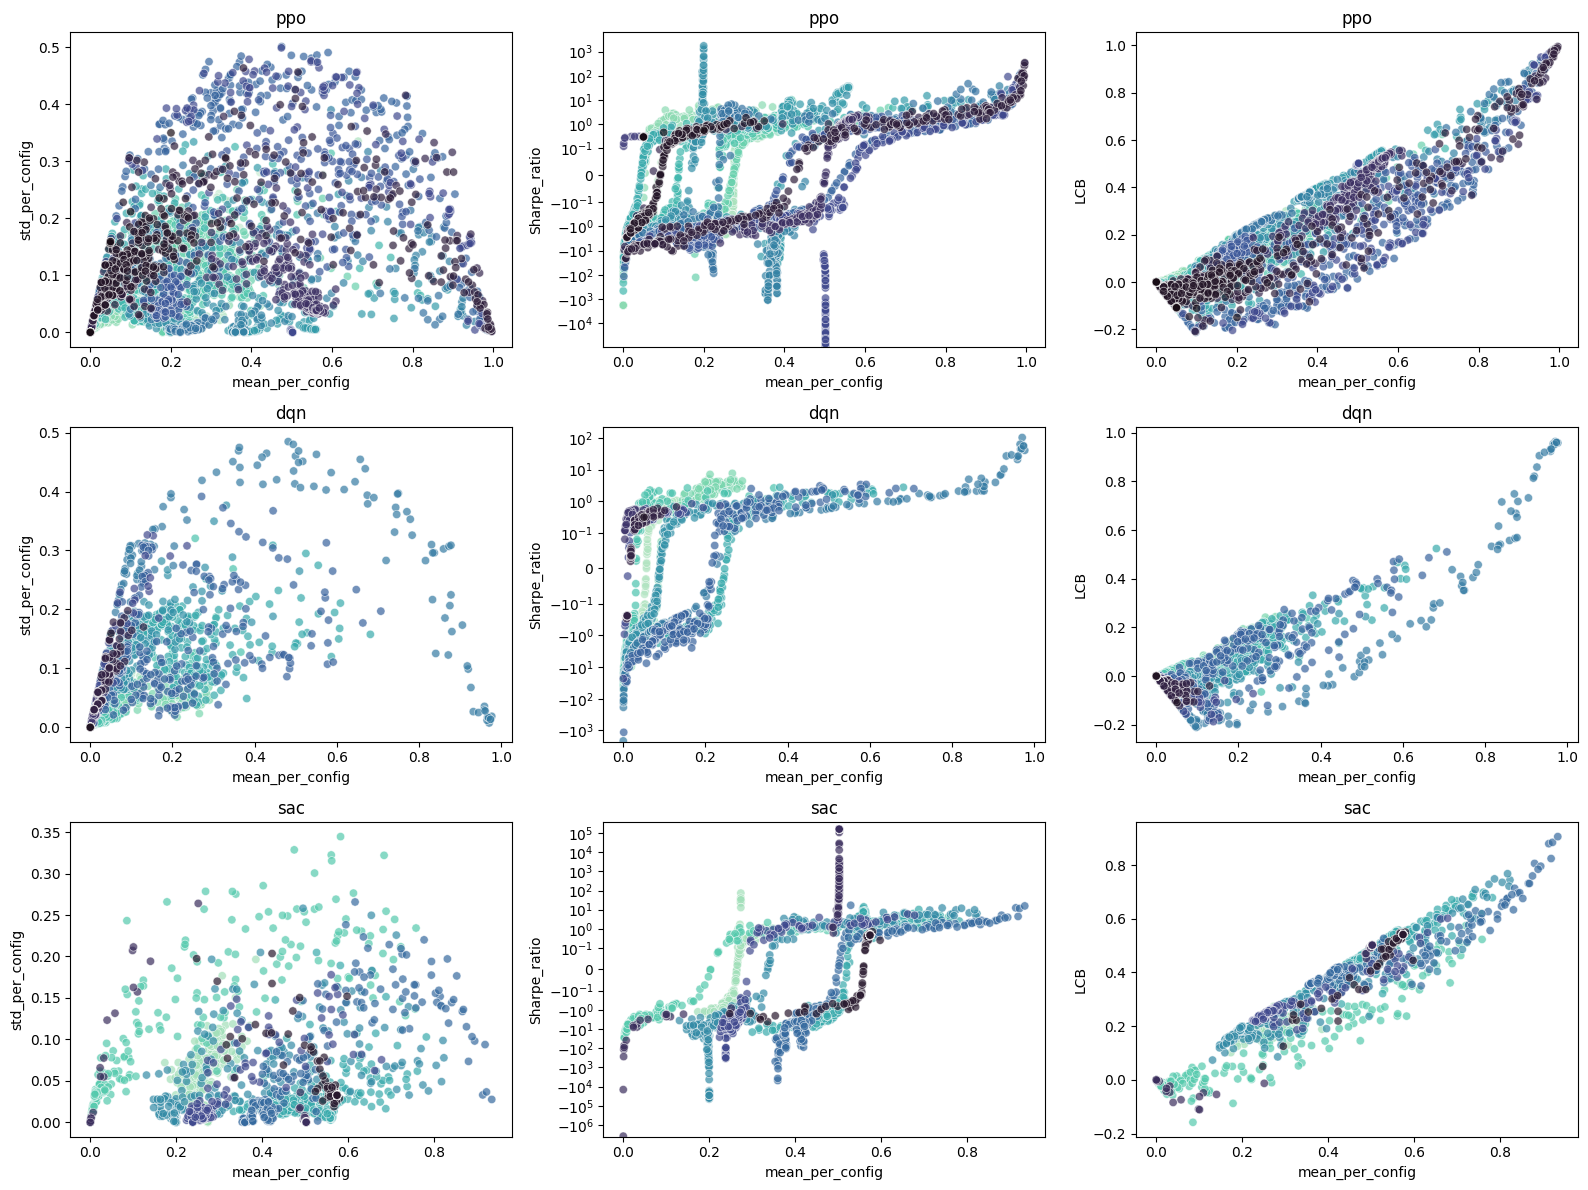

In [8]:
algos = data["algorithm"].unique()
per_alg_plot(
    plot_data=config_stats,
    x="mean_per_config",
    ycols=["std_per_config", "Sharpe_ratio", "LCB"],
    algs=algos
)

In [12]:
metrics = {}

for alg in algos:
    alg_data = config_stats[config_stats["algorithm"] == alg]

    perfs, perfs_sharpe, vars, vars_sharpe, perfs_lcb, vars_lcb = [], [], [], [], [], []
    
    for env in alg_data["env_name"].unique():
        env_data = alg_data[alg_data["env_name"] == env]

        config_idx = env_data["mean_per_config"].idxmax()
        config_idx_sharpe = env_data["Sharpe_ratio"].idxmax()
        config_idx_lcb = env_data["LCB"].idxmax()

        perfs.append(env_data.loc[config_idx, "mean_per_config"])
        perfs_sharpe.append(env_data.loc[config_idx_sharpe, "mean_per_config"])
        perfs_lcb.append(env_data.loc[config_idx_lcb, "mean_per_config"])
        vars.append(env_data.loc[config_idx, "std_per_config"])
        vars_sharpe.append(env_data.loc[config_idx_sharpe, "std_per_config"])
        vars_lcb.append(env_data.loc[config_idx_lcb, "std_per_config"])
    
    mean_perf = np.mean(perfs)
    mean_perf_sharpe = np.mean(perfs_sharpe)
    mean_perf_lcb = np.mean(perfs_lcb)
    mean_var = np.mean(vars)
    mean_var_sharpe = np.mean(vars_sharpe)
    mean_var_lcb = np.mean(vars_lcb)


    metrics[alg] = {
        "perf": mean_perf,
        "perf_sharpe": mean_perf_sharpe,
        "perf_lcb": mean_perf_lcb,
        "var": mean_var,
        "var_sharpe": mean_var_sharpe,
        "var_lcb": mean_var_lcb,
    }

df = pd.DataFrame(metrics).T.reset_index().rename(columns={"index": "algorithm"})

df
        


,algorithm,perf,perf_sharpe,perf_lcb,var,var_sharpe,var_lcb
0,ppo,0.696318,0.635138,0.669966,0.103550,0.069017,0.052274
1,dqn,0.377903,0.336919,0.328541,0.150797,0.107381,0.073820
2,sac,0.682123,0.572392,0.662395,0.108329,0.032173,0.047459


In [17]:

# n_cols = 3
# algos = data["algorithm"].unique()

# fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# axes = axes.flatten()

# for i, alg in enumerate(algos):
    
#     sub_data = config_stats[config_stats["algorithm"] == alg]

   
#     sns.scatterplot(
#         data=sub_data,
#         x="mean_per_config",
#         y="std_per_config",
#         hue="env_name",
#         ax=axes[i],
#         alpha=0.7,
#         palette=sns.color_palette("mako", n_colors=len(sub_data["env_name"].unique()))[::-1]
#     )

#     axes[i].set_xlabel("Mean Performance")

#     axes[i].set_ylabel("Std. Deviation of Performance")
#     # axes[i].set_title(alg)

    
#     axes[i].legend().set_visible(False)

 

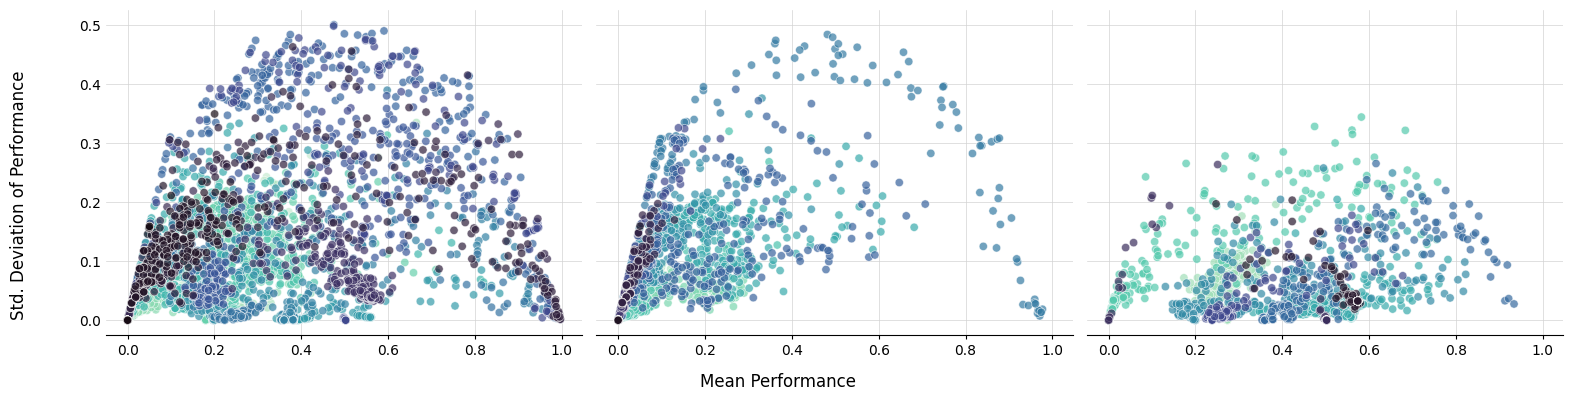

In [18]:
n_cols = 3
algos = data["algorithm"].unique()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True, sharex=True)
axes = axes.flatten()

# Calculate global limits
all_data = config_stats[config_stats["algorithm"].isin(algos)]
x_min, x_max = all_data["mean_per_config"].min(), all_data["mean_per_config"].max()
y_min, y_max = all_data["std_per_config"].min(), all_data["std_per_config"].max()
x_margin = (x_max - x_min) * 0.05
y_margin = (y_max - y_min) * 0.05

for i, alg in enumerate(algos):
    
    sub_data = config_stats[config_stats["algorithm"] == alg]

    sns.scatterplot(
        data=sub_data,
        x="mean_per_config",
        y="std_per_config",
        hue="env_name",
        ax=axes[i],
        alpha=0.7,
        palette=sns.color_palette("mako", n_colors=len(sub_data["env_name"].unique()))[::-1]
    )

    # axes[i].set_title(alg.upper())
    
    # Remove individual axis labels (will use joint labels)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    
    # Set same limits
    axes[i].set_xlim(x_min - x_margin, x_max + x_margin)
    axes[i].set_ylim(y_min - y_margin, y_max + y_margin)
    
    # Horizontal and vertical grid lines in light grey
    axes[i].xaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    axes[i].yaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    axes[i].set_axisbelow(True)
    
    # Remove all spines except bottom
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_visible(False)
    
    # Remove y ticks but keep labels
    axes[i].tick_params(axis='y', length=0)
    axes[i].tick_params(axis='x', length=3)
    
    # Hide legend
    axes[i].legend().set_visible(False)

# Joint labels
fig.supylabel("Std. Deviation of Performance", fontsize=12)
fig.supxlabel("Mean Performance", fontsize=12)

plt.tight_layout()
plt.subplots_adjust(left=0.08, bottom=0.15)  # Make room for joint labels
plt.savefig("_figures/mean_std_per_alg.pdf")

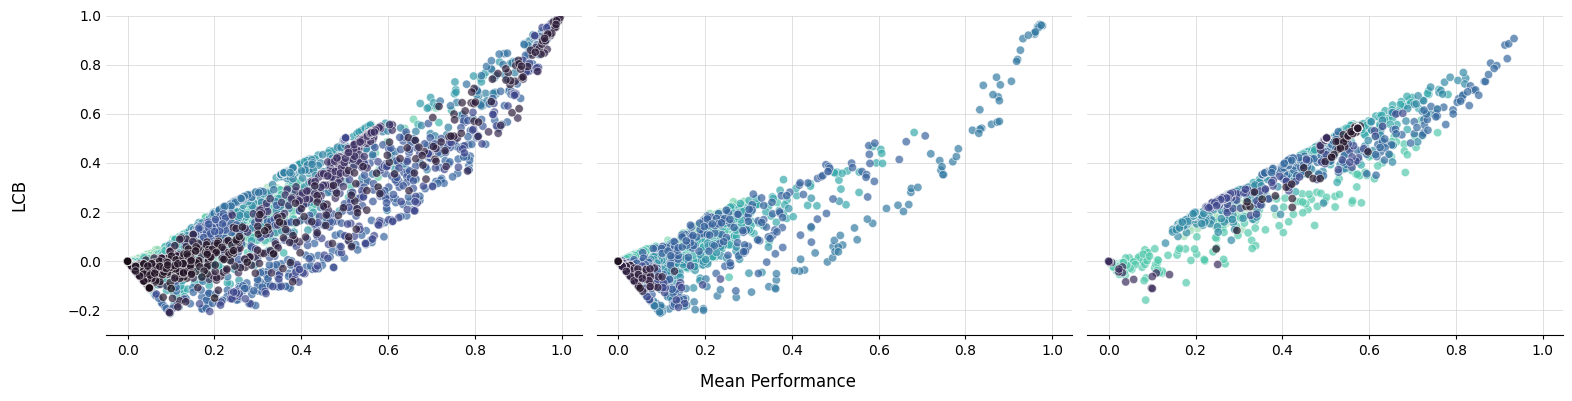

In [22]:
n_cols = 3
algos = data["algorithm"].unique()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True, sharex=True)
axes = axes.flatten()

# Calculate global limits
all_data = config_stats[config_stats["algorithm"].isin(algos)]
x_min, x_max = all_data["mean_per_config"].min(), all_data["mean_per_config"].max()
y_min, y_max = all_data["std_per_config"].min(), all_data["std_per_config"].max()
x_margin = (x_max - x_min) * 0.05
y_margin = (y_max - y_min) * 0.05

for i, alg in enumerate(algos):
    
    sub_data = config_stats[config_stats["algorithm"] == alg]

    sns.scatterplot(
        data=sub_data,
        x="mean_per_config",
        y="LCB",
        hue="env_name",
        ax=axes[i],
        alpha=0.7,
        palette=sns.color_palette("mako", n_colors=len(sub_data["env_name"].unique()))[::-1]
    )

    # axes[i].set_title(alg.upper())
    
    # Remove individual axis labels (will use joint labels)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    
    # Set same limits
    axes[i].set_xlim(x_min - x_margin, x_max + x_margin)
    axes[i].set_ylim(-0.3, 1.0)
    
    # Horizontal and vertical grid lines in light grey
    axes[i].xaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    axes[i].yaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    axes[i].set_axisbelow(True)
    
    # Remove all spines except bottom
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_visible(False)
    
    # Remove y ticks but keep labels
    axes[i].tick_params(axis='y', length=0)
    axes[i].tick_params(axis='x', length=3)
    
    # Hide legend
    axes[i].legend().set_visible(False)

# Joint labels
fig.supylabel("LCB", fontsize=12)
fig.supxlabel("Mean Performance", fontsize=12)

plt.tight_layout()
plt.subplots_adjust(left=0.08, bottom=0.15)  # Make room for joint labels
plt.savefig("_figures/mean_LCB_per_alg.pdf")

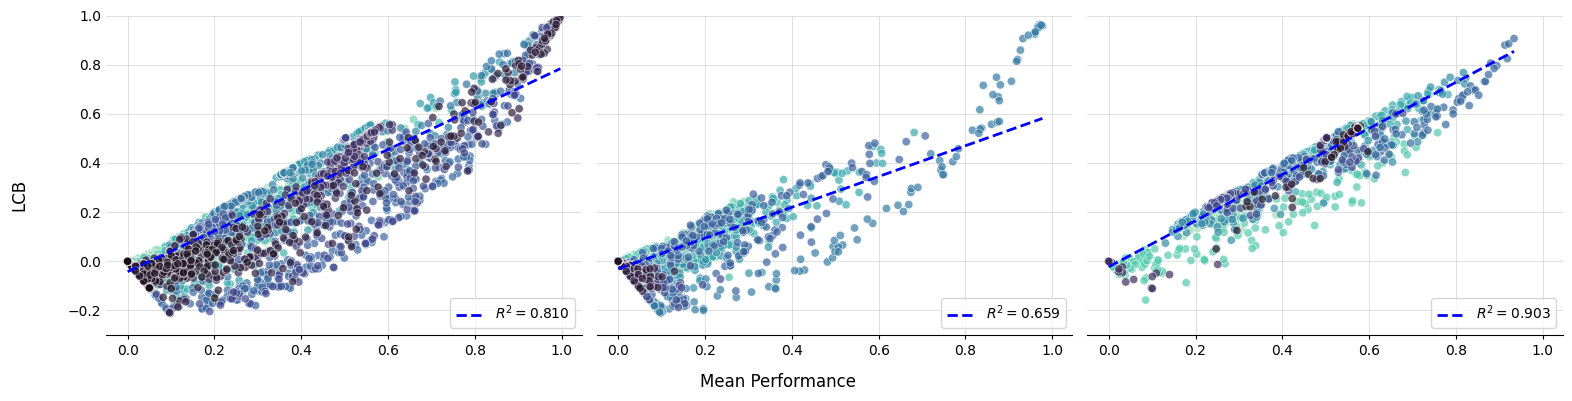

In [25]:

n_cols = 3
algos = data["algorithm"].unique()

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True, sharex=True)
axes = axes.flatten()

# Calculate global limits
all_data = config_stats[config_stats["algorithm"].isin(algos)]
x_min, x_max = all_data["mean_per_config"].min(), all_data["mean_per_config"].max()
y_min, y_max = all_data["std_per_config"].min(), all_data["std_per_config"].max()
x_margin = (x_max - x_min) * 0.05
y_margin = (y_max - y_min) * 0.05

for i, alg in enumerate(algos):
    
    sub_data = config_stats[config_stats["algorithm"] == alg]

    sns.scatterplot(
        data=sub_data,
        x="mean_per_config",
        y="LCB",
        hue="env_name",
        ax=axes[i],
        alpha=0.7,
        palette=sns.color_palette("mako", n_colors=len(sub_data["env_name"].unique()))[::-1],
        legend=False  # Disable seaborn legend
    )

    # Linear regression
    x = sub_data["mean_per_config"].values
    y = sub_data["LCB"].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r_squared = r_value ** 2
    
    # Plot regression line
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    axes[i].plot(x_line, y_line, color='blue', linestyle='--', linewidth=2, label=f'$R^2 = {r_squared:.3f}$')
    
    # Add legend for R² only
    axes[i].legend(loc='lower right', frameon=True, fontsize=10)
    
    # Remove individual axis labels (will use joint labels)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    
    # Set same limits
    axes[i].set_xlim(x_min - x_margin, x_max + x_margin)
    axes[i].set_ylim(-0.3, 1.0)
    
    # Horizontal and vertical grid lines in light grey
    axes[i].xaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    axes[i].yaxis.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    axes[i].set_axisbelow(True)
    
    # Remove all spines except bottom
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_visible(False)
    
    # Remove y ticks but keep labels
    axes[i].tick_params(axis='y', length=0)
    axes[i].tick_params(axis='x', length=3)

# Joint labels
fig.supylabel("LCB", fontsize=12)
fig.supxlabel("Mean Performance", fontsize=12)

plt.tight_layout()
plt.subplots_adjust(left=0.08, bottom=0.15)  # Make room for joint labels
plt.savefig("_figures/mean_LCB_per_alg.pdf")